# Análisis del comportamiento histórico de Bitcoin: riesgo, volatilidad y dinámica de volumen

### Abstract

Bitcoin se ha consolidado como el principal activo digital del mercado, caracterizado por elevados niveles de volatilidad y un comportamiento influenciado por la dinámica de oferta y demanda. Si bien su rentabilidad histórica ha sido notable, también ha presentado fuertes movimientos extremos que lo convierten en un activo de alto riesgo relativo.

El presente proyecto tiene como objetivo analizar el comportamiento histórico de Bitcoin utilizando datos obtenidos desde una API pública. Se estudiará la distribución de sus retornos diarios, su nivel de volatilidad, la magnitud de sus caídas acumuladas y la relación entre movimientos de precio y volumen negociado.

La audiencia objetivo incluye inversores minoristas, analistas financieros junior y profesionales interesados en comprender, desde una perspectiva cuantitativa, el perfil de riesgo del activo.

## Preguntas de investigación

1. ¿Cómo se distribuyen los retornos diarios de Bitcoin?

2. ¿Cuál es su nivel de volatilidad diaria y anual?

3. ¿Con qué frecuencia ocurren movimientos extremos?

4. ¿Cuál ha sido la magnitud de sus principales caídas acumuladas?

5. ¿Existe relación entre variaciones fuertes de precio y cambios en el volumen negociado?

6. ¿El volumen aumenta durante períodos de alta volatilidad?





## Obtención de datos históricos mediante Yahoo Finance

Dado que la API pública de CoinGecko limita el acceso a datos históricos completos, se utilizará la librería yfinance, que permite descargar información histórica de mercado directamente desde Yahoo Finance.

Se obtendrán datos diarios de Bitcoin (BTC-USD), incluyendo:

* Precio de apertura

* Precio máximo

* Precio mínimo

* Precio de cierre

* Volumen negociado

In [24]:
# IMPORTACION DE LIBRERIAS
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use("default")


In [25]:
# Instalamos la libreira

!pip install -qq yfinance

import yfinance as yf

# Descargamos datos históricos completos
df = yf.download("BTC-USD", start="2015-01-01")

df.reset_index(inplace=True)

df.to_csv("bitcoin_historico.csv", index=False)

df.head()

/tmp/ipython-input-3334781387.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2015-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


Resumen del dataset

Antes de comenzar con el análisis exploratorio, se presenta un resumen general del dataset obtenido, incluyendo cantidad de observaciones, variables disponibles y período temporal cubierto.

In [26]:
# Dimensiones del dataset
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])
print("\n")

# Tipos de datos
print("Tipos de variables:")
print(df.dtypes)
print("\n")

# Rango temporal
print("Fecha mínima:", df["Date"].min())
print("Fecha máxima:", df["Date"].max())


Cantidad de filas: 4066
Cantidad de columnas: 6


Tipos de variables:
Price   Ticker 
Date               datetime64[ns]
Close   BTC-USD           float64
High    BTC-USD           float64
Low     BTC-USD           float64
Open    BTC-USD           float64
Volume  BTC-USD             int64
dtype: object


Fecha mínima: 2015-01-01 00:00:00
Fecha máxima: 2026-02-17 00:00:00


Limpieza y verificación de datos

Se verificará la existencia de valores nulos y se preparará el dataset para el análisis posterior.

In [27]:
# Verificamos valores nulos
df.isnull().sum()


,,0
Price,Ticker,
Date,,0
Close,BTC-USD,0
High,BTC-USD,0
Low,BTC-USD,0
Open,BTC-USD,0
Volume,BTC-USD,0


### Ingeniería de atributos

Con el objetivo de enriquecer el análisis, se crearán nuevas variables derivadas del precio y del volumen. Estas permitirán estudiar el comportamiento del activo desde una perspectiva de riesgo y dinámica de mercado.

Se calcularán:

* Retorno diario porcentual

* Retorno acumulado

* Volatilidad móvil (30 días)

* Variación porcentual del volumen

* Identificación de eventos extremos

* Identificación de caídas severas

In [28]:
# Aplanar columnas (por si viene con MultiIndex de yfinance)
df.columns = df.columns.get_level_values(0)
# Asegurarse de que no quede ningún nombre de MultiIndex para las columnas
df.columns.name = None

# Renombrar columnas originales al español
df = df.rename(columns={
    "Date": "fecha",
    "Open": "apertura",
    "High": "maximo",
    "Low": "minimo",
    "Close": "cierre",
    "Volume": "volumen"
})

# Eliminar columnas derivadas con nombres en inglés si existen de una ejecución anterior
english_derived_cols = [
    "return_pct", "cumulative_return", "rolling_volatility_30d",
    "volume_change_pct", "extreme_event", "severe_drop"
]
df = df.drop(columns=[col for col in english_derived_cols if col in df.columns], errors='ignore')

# Retorno diario porcentual
df["retorno_pct"] = df["cierre"].pct_change() * 100

# Retorno acumulado (base 100)
df["retorno_acumulado"] = (1 + df["cierre"].pct_change()).cumprod() * 100

# Volatilidad móvil 30 días (desviación estándar de retornos)
df["volatilidad_movil_30d"] = df["retorno_pct"].rolling(window=30).std()

# Cambio porcentual en volumen
df["cambio_volumen_pct"] = df["volumen"].pct_change() * 100

# Evento extremo (movimientos mayores al 5% en valor absoluto)
df["evento_extremo"] = df["retorno_pct"].abs() > 5

# Caída severa (retornos menores a -5%)
df["caida_severa"] = df["retorno_pct"] < -5

df.head()

,fecha,cierre,maximo,minimo,apertura,volumen,retorno_pct,retorno_acumulado,volatilidad_movil_30d,cambio_volumen_pct,evento_extremo,caida_severa
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,NaN,NaN,NaN,NaN,False,False
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,0.249172,100.249172,NaN,-2.188750,False,False
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-10.776686,89.445633,NaN,320.504666,True,True
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,-6.007853,84.071871,NaN,68.295598,True,True
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,3.890684,87.342841,NaN,-20.971578,False,False


A continuación, exploraremos las preguntas de investigación planteadas para este estudio, desglosando el comportamiento histórico de Bitcoin a través de diferentes métricas clave.

## Pregunta 1:

¿Cómo se distribuyen los retornos diarios?

Esto nos dirá:

Qué tan frecuente son movimientos grandes

Si la distribución es normal o tiene colas pesadas

Si hay asimetría (más caídas fuertes que subas fuertes)

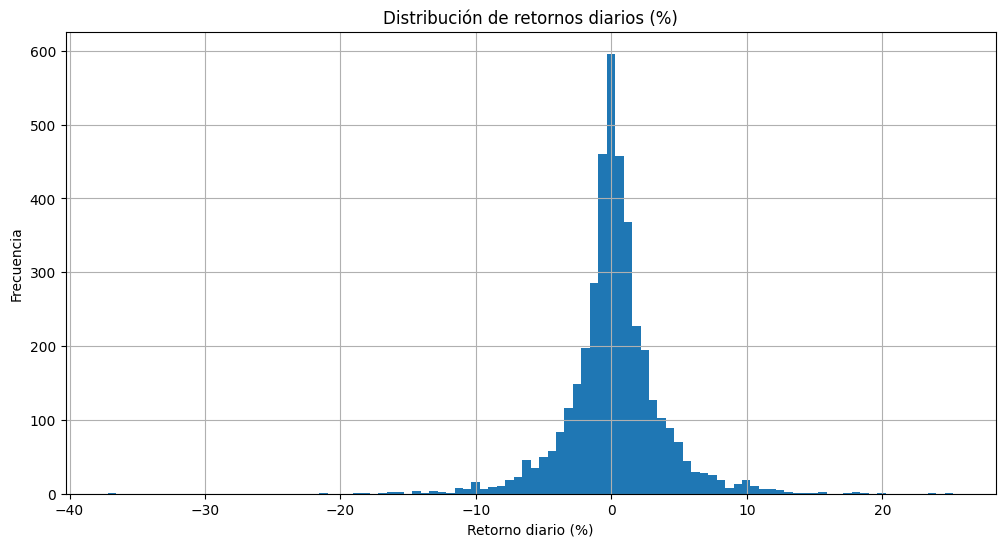

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6)) # Aumentamos el tamaño de la figura para mejor legibilidad
plt.hist(df["retorno_pct"].dropna(), bins=100)
plt.title("Distribución de retornos diarios (%)")
plt.xlabel("Retorno diario (%)")
plt.ylabel("Frecuencia")
plt.grid(True) # Añadimos una cuadrícula
plt.show()

In [30]:
df["retorno_pct"].describe()


,retorno_pct
count,4065.000000
mean,0.194836
std,3.521878
min,-37.169539
25%,-1.222510
50%,0.120073
75%,1.599232
max,25.247169


In [31]:
print(f"Asimetría (Skewness): {df['retorno_pct'].skew()}")
print(f"Curtosis (Kurtosis): {df['retorno_pct'].kurtosis()}")

Asimetría (Skewness): -0.12162770608243957
Curtosis (Kurtosis): 7.961802960004908


## Pregunta 2:

¿Cuál es su nivel de volatilidad diaria y anual?

Esto nos dirános dará información clave sobre la estabilidad del precio del activo y el riesgo asociado a sus movimientos.

In [32]:
# Volatilidad diaria promedio

# La volatilidad diaria es simplemente la desviación estándar de los retornos diarios.

vol_diaria = df["retorno_pct"].std()

print(f"Volatilidad diaria promedio: {vol_diaria:.2f}%")

Volatilidad diaria promedio: 3.52%


In [33]:
# Volatilidad anualizada

# En finanzas, la volatilidad anual se calcula como:

# (252 días bursátiles como convención estándar)

vol_anual = vol_diaria * np.sqrt(252)

print(f"Volatilidad anualizada: {vol_anual:.2f}%")

Volatilidad anualizada: 55.91%


In [34]:
# Volatilidad anual histórica (más profesional)

# Ahora calculamos la volatilidad por año calendario:

df["año"] = df["fecha"].dt.year

vol_por_año = df.groupby("año")["retorno_pct"].std() * np.sqrt(252)

print(vol_por_año)

año
2015    57.213154
2016    39.901741
2017    79.244210
2018    67.356515
2019    56.550914
2020    59.859944
2021    66.816000
2022    52.796688
2023    36.365280
2024    44.495414
2025    34.832221
2026    55.560635
Name: retorno_pct, dtype: float64


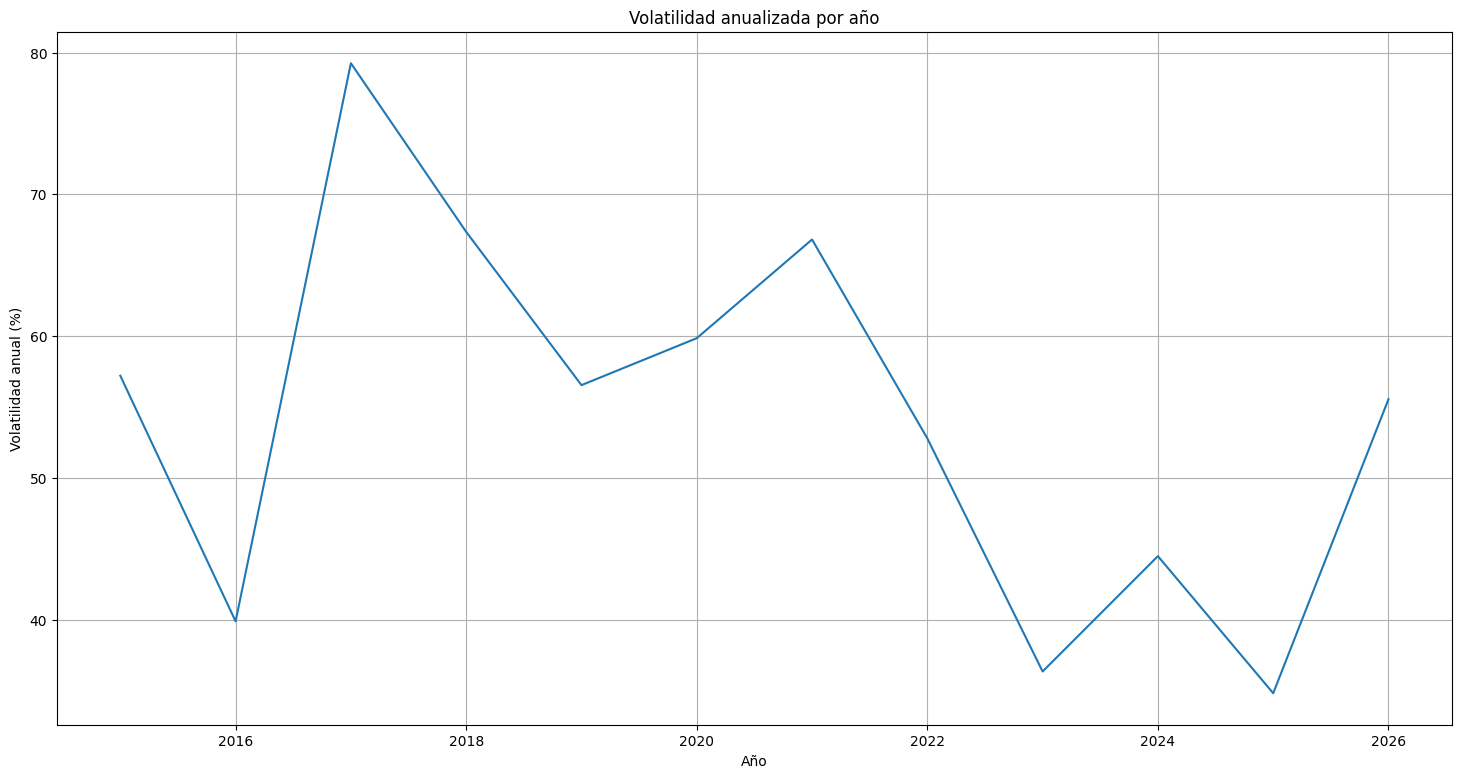

In [35]:
#Gráfico de volatilidad anual

plt.figure(figsize=(18, 9))
plt.plot(vol_por_año.index, vol_por_año.values)
plt.title("Volatilidad anualizada por año")
plt.xlabel("Año")
plt.ylabel("Volatilidad anual (%)")
plt.grid(True)
plt.show()

## Pregunta 3:

¿Con qué frecuencia ocurren movimientos extremos?

Esto nos permitirá evaluar qué tan frecuentes son las variaciones bruscas del precio y medir el nivel de inestabilidad del activo.

In [36]:
# Ya definimos:

# df["evento_extremo"] = df["retorno_pct"].abs() > 5

#Ahora lo cuantificamos formalmente.

# Cantidad total de eventos extremos
total_eventos = df["evento_extremo"].sum()
print("Total de eventos extremos:", total_eventos)

Total de eventos extremos: 489


In [37]:
# Porcentaje sobre el total de días
total_dias = len(df)

porcentaje_eventos = (total_eventos / total_dias) * 100

print(f"Porcentaje de días con eventos extremos: {porcentaje_eventos:.2f}%")

Porcentaje de días con eventos extremos: 12.03%


In [38]:
# Eventos extremos por año
eventos_por_año = df.groupby("año")["evento_extremo"].sum()

print(eventos_por_año)

año
2015    39
2016    21
2017    96
2018    74
2019    39
2020    40
2021    75
2022    37
2023    23
2024    27
2025    14
2026     4
Name: evento_extremo, dtype: int64


In [39]:
# Frecuencia relativa anual
dias_por_año = df.groupby("año")["evento_extremo"].count()

frecuencia_anual = (eventos_por_año / dias_por_año) * 100

print(frecuencia_anual)

año
2015    10.684932
2016     5.737705
2017    26.301370
2018    20.273973
2019    10.684932
2020    10.928962
2021    20.547945
2022    10.136986
2023     6.301370
2024     7.377049
2025     3.835616
2026     8.333333
Name: evento_extremo, dtype: float64


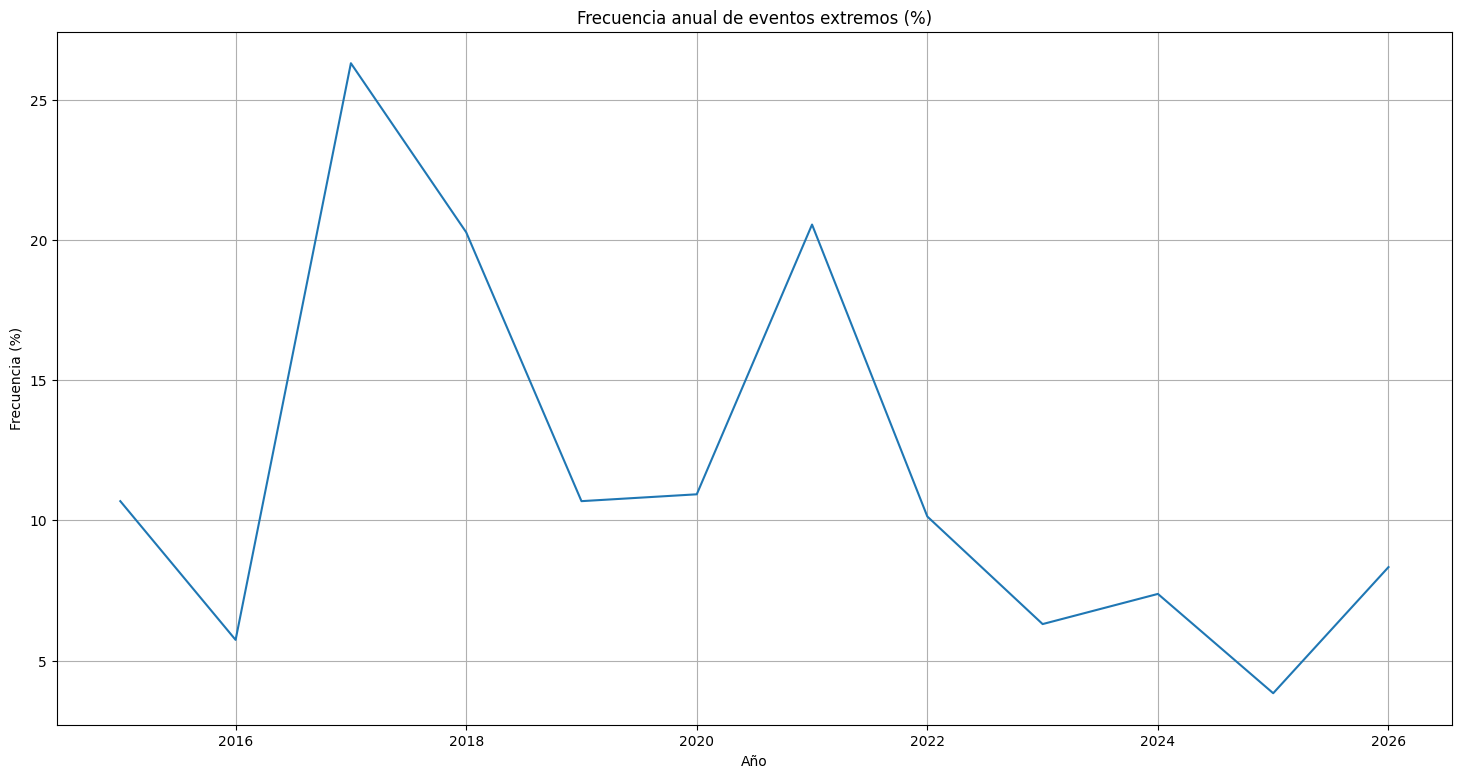

In [40]:
# Visualización

plt.figure(figsize=(18, 9))
plt.plot(frecuencia_anual.index, frecuencia_anual.values)
plt.title("Frecuencia anual de eventos extremos (%)")
plt.xlabel("Año")
plt.ylabel("Frecuencia (%)")
plt.grid(True)
plt.show()

## Pregunta 4:

¿Cuál ha sido la magnitud de sus principales caídas acumuladas?

Esto nos permitirá medir la profundidad de las caídas históricas y evaluar el nivel de riesgo asociado a los ciclos bajistas del activo.



In [41]:
# Calculamos el drawdown
# Aseguramos orden cronológico
df = df.sort_values("fecha").reset_index(drop=True)

# Máximo acumulado histórico
df["max_acumulado"] = df["cierre"].cummax()

# Drawdown porcentual
df["drawdown_pct"] = (df["cierre"] / df["max_acumulado"] - 1) * 100

In [42]:
# Magnitud del peor drawdown
max_drawdown = df["drawdown_pct"].min()

print(f"Drawdown máximo histórico: {max_drawdown:.2f}%")

# Ese número responde directamente a cual fue la peor caída acumulada

Drawdown máximo histórico: -83.40%


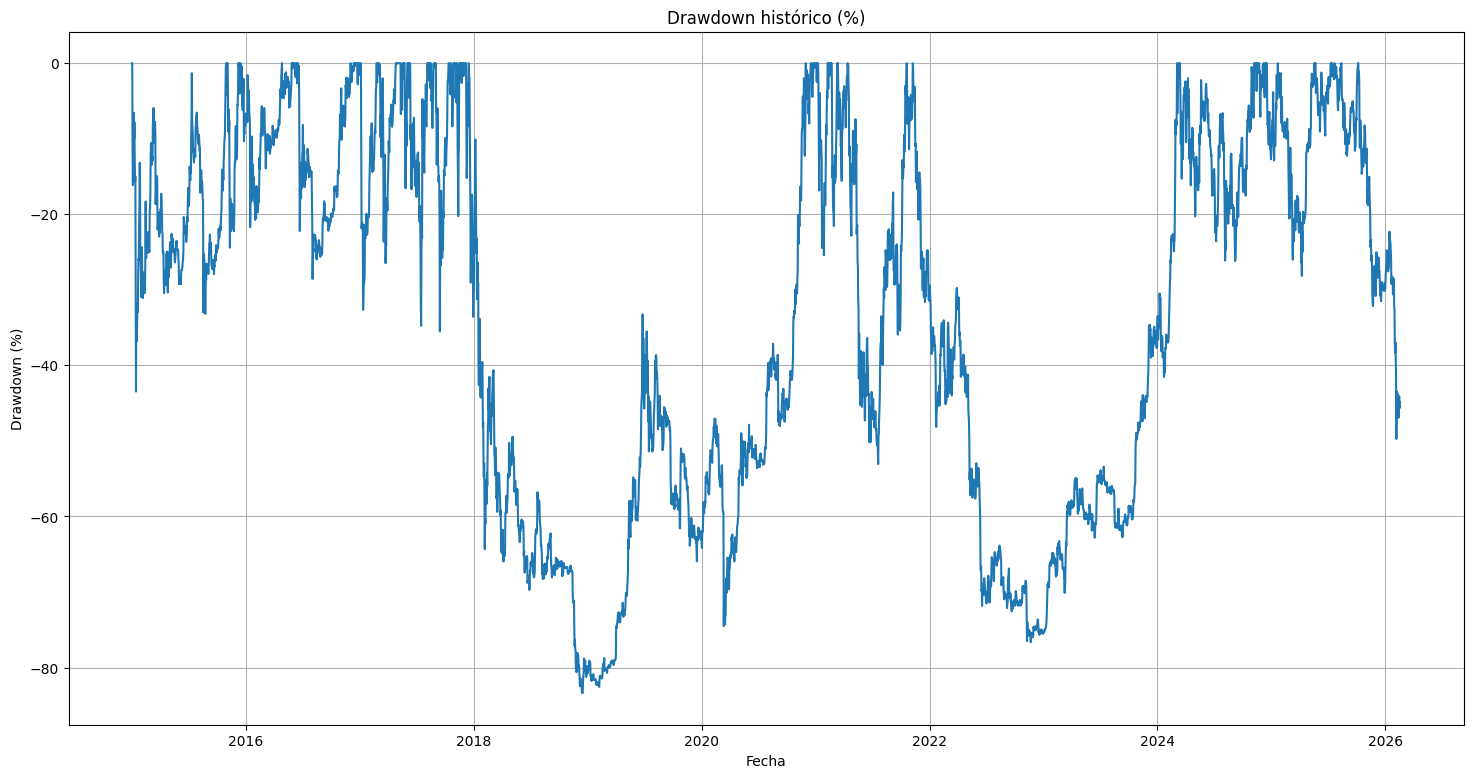

In [43]:
# Curva completa de drawdown

plt.figure(figsize=(18, 9))
plt.plot(df["fecha"], df["drawdown_pct"])
plt.title("Drawdown histórico (%)")
plt.xlabel("Fecha")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.show()

In [44]:
# Identificamos las principales caídas (Top 5)

# En vez de quedarnos solo con la peor, vamos a listar las más profundas.

top_drawdowns = df.nsmallest(5, "drawdown_pct")[["fecha", "drawdown_pct"]]

print(top_drawdowns)

# Esto te mostrará las fechas donde el mercado estuvo más deprimido respecto a su máximo previo.

          fecha  drawdown_pct
1444 2018-12-15    -83.399009
1443 2018-12-14    -83.369655
1445 2018-12-16    -83.316550
1442 2018-12-13    -83.004518
1498 2019-02-07    -82.564488


## Pregunta 5:

¿Existe relación entre variaciones fuertes de precio y cambios en el volumen negociado?


Esto nos permitirá determinar si los movimientos bruscos de precio están acompañados por cambios significativos en la actividad del mercado.


In [45]:
# Ahora cruzamos:

# -retorno_pct
# -cambio_volumen_pct
# -evento_extremo

# Análisis relacional

# Correlación simple precio–volumen
correlacion = df["retorno_pct"].corr(df["cambio_volumen_pct"])

print(f"Correlación entre retorno y cambio de volumen: {correlacion:.4f}")

Correlación entre retorno y cambio de volumen: 0.0298


In [46]:
# ¿El volumen cambia más en días extremos?

# Comparamos volumen en días normales vs extremos.

vol_extremos = df[df["evento_extremo"]]["cambio_volumen_pct"].mean()
vol_normales = df[~df["evento_extremo"]]["cambio_volumen_pct"].mean()

print(f"Cambio promedio volumen en días extremos: {vol_extremos:.2f}%")
print(f"Cambio promedio volumen en días normales: {vol_normales:.2f}%")

Cambio promedio volumen en días extremos: 37.01%
Cambio promedio volumen en días normales: 1.78%


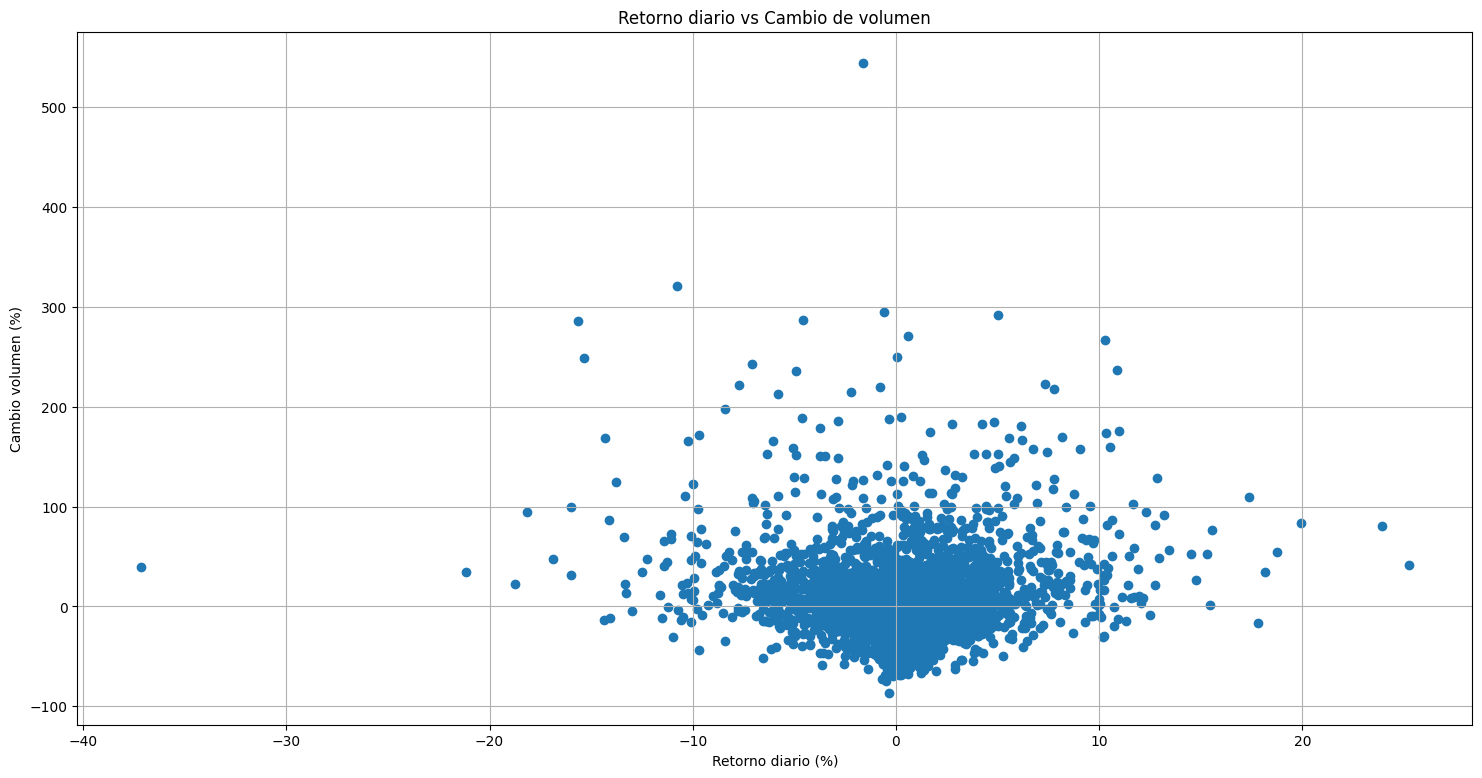

In [47]:
# Visualización dispersión (scatter plot)

plt.figure(figsize=(18, 9))
plt.scatter(df["retorno_pct"], df["cambio_volumen_pct"])
plt.title("Retorno diario vs Cambio de volumen")
plt.xlabel("Retorno diario (%)")
plt.ylabel("Cambio volumen (%)")
plt.grid(True)
plt.show()

## Pregunta 6:

¿El volumen aumenta durante períodos de alta volatilidad?

Esto nos permitirá evaluar si los períodos de mayor incertidumbre están asociados con un incremento sostenido en la actividad de negociación.



In [48]:
# Ahora no miramos días extremos aislados, sino regímenes de alta volatilidad.

# Vamos a trabajar con:

# - volatilidad_movil_30d

# - cambio_volumen_pct

In [49]:
# Correlación entre volatilidad y volumen

# Primero vemos si existe relación lineal:

correlacion_vol = df["volatilidad_movil_30d"].corr(df["cambio_volumen_pct"])

print(f"Correlación entre volatilidad móvil y cambio de volumen: {correlacion_vol:.4f}")

Correlación entre volatilidad móvil y cambio de volumen: -0.0332


In [50]:
# Comparar períodos de alta vs baja volatilidad

# Definimos alta volatilidad como valores por encima del percentil 75:

umbral_alta_vol = df["volatilidad_movil_30d"].quantile(0.75)

df["alta_volatilidad"] = df["volatilidad_movil_30d"] > umbral_alta_vol

# Ahora comparamos volumen:

vol_alta = df[df["alta_volatilidad"]]["cambio_volumen_pct"].mean()
vol_baja = df[~df["alta_volatilidad"]]["cambio_volumen_pct"].mean()

print(f"Cambio promedio de volumen en alta volatilidad: {vol_alta:.2f}%")
print(f"Cambio promedio de volumen en baja volatilidad: {vol_baja:.2f}%")

Cambio promedio de volumen en alta volatilidad: 2.99%
Cambio promedio de volumen en baja volatilidad: 7.02%


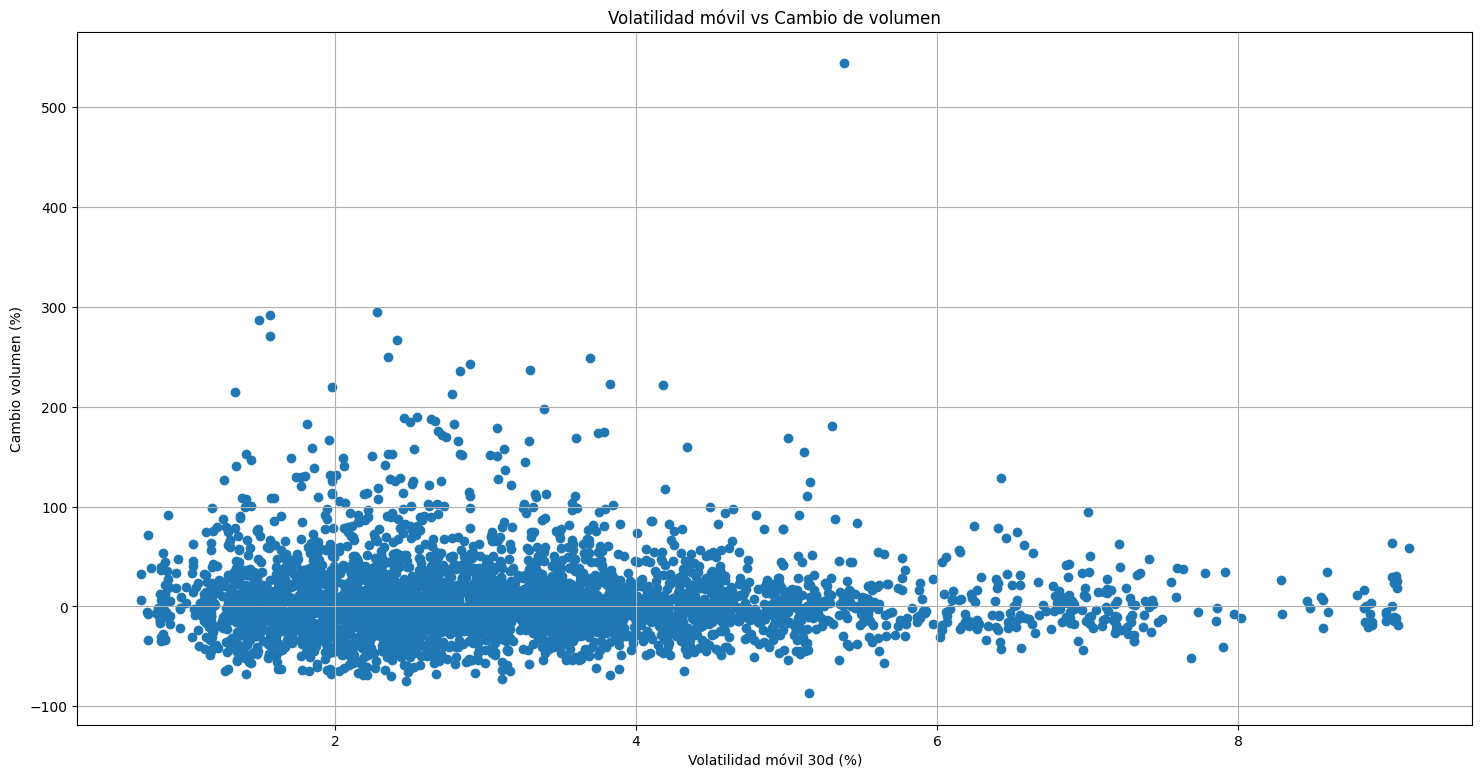

In [51]:
# Visualización

plt.figure(figsize=(18, 9))
plt.scatter(df["volatilidad_movil_30d"], df["cambio_volumen_pct"])
plt.title("Volatilidad móvil vs Cambio de volumen")
plt.xlabel("Volatilidad móvil 30d (%)")
plt.ylabel("Cambio volumen (%)")
plt.grid(True)
plt.show()

# CONCLUSIONES DEL ANÁLISIS

El estudio analiza el comportamiento histórico de Bitcoin a través de retornos diarios, volatilidad, eventos extremos, drawdowns y relación con el volumen negociado.

### 1- Distribución de retornos diarios

* Los retornos diarios presentan:

* Media: 0.19%

* Desviación estándar: 3.52%

* Curtosis: 7.96

* Asimetría: -0.12

La curtosis elevada indica presencia de colas pesadas, lo que implica mayor probabilidad de eventos extremos que en una distribución normal.

La asimetría ligeramente negativa sugiere que las caídas fuertes tienden a ser marginalmente más pronunciadas que las subidas extremas.

*Conclusión*: Bitcoin no sigue una distribución normal y presenta alta probabilidad de movimientos abruptos.

### 2- Volatilidad diaria y anual

* Volatilidad diaria promedio: 3.52%

* Volatilidad anualizada: 55.91%

Se observan años con volatilidad superior al 70% (ej. 2017), y períodos más moderados cercanos al 35%.

*Conclusión*: Bitcoin exhibe volatilidad estructuralmente elevada, muy superior a activos tradicionales, lo que implica alto riesgo pero también potencial de rendimiento.

### 3- Frecuencia de movimientos extremos

* Total eventos >5%: 489

Representan 12.03% de los días

En 2017 y 2018 la frecuencia superó el 20% anual.

*Conclusión*: Aproximadamente 1 de cada 8 días presenta movimientos extremos, confirmando alta inestabilidad diaria.

### 4- Magnitud de principales caídas acumuladas

* Drawdown máximo histórico: -83.40%

Ocurrió en diciembre de 2018.

Esto implica que desde un máximo histórico el precio llegó a perder más del 80% antes de recuperar.

*Conclusión*: Bitcoin presenta caídas acumuladas extremadamente profundas, lo que evidencia alto riesgo temporal para inversores.

### 5- Relación entre retornos y volumen

* Correlación retorno–volumen: 0.0298 (muy baja)

* Cambio promedio volumen en días extremos: 37.01%

* En días normales: 1.78%

Aunque la correlación lineal es débil, los días extremos muestran aumentos significativos en volumen.

*Conclusión*: Los shocks de precio están acompañados por fuerte actividad de mercado.

### 6- Volumen durante períodos de alta volatilidad

* Correlación volatilidad–volumen: -0.0332

* Volumen promedio en alta volatilidad: 2.98%

* En baja volatilidad: 7.02%

No se observa relación positiva estructural entre regímenes de alta volatilidad y aumento sostenido de volumen.

*Conclusión*: El volumen reacciona a shocks puntuales más que a regímenes prolongados de volatilidad elevada.



# RESUMEN EJECUTIVO

Bitcoin presenta:

* Alta volatilidad estructural (~56% anual)

* Frecuencia elevada de movimientos extremos (12% de los días)

* Drawdowns históricos profundos (-83%)

* Aumento significativo del volumen en días de shock

* Ausencia de relación fuerte entre volatilidad prolongada y volumen

En términos generales:

Bitcoin es un activo de alto riesgo y alta variabilidad, caracterizado por episodios recurrentes de movimientos extremos y ciclos profundos de caída, aunque con fuerte crecimiento en el largo plazo.

El volumen actúa como amplificador en días críticos, pero no necesariamente aumenta de forma sostenida durante períodos prolongados de volatilidad.

## CIERRE

El análisis confirma que Bitcoin no se comporta como un activo tradicional, ya que presenta colas pesadas en la distribución de sus retornos y un nivel de riesgo extremo. Asimismo, exhibe ciclos de mercado pronunciados, con fases expansivas y contractivas marcadas, lo que implica que su inversión requiere una elevada tolerancia al riesgo y capacidad para soportar fuertes fluctuaciones temporales.